# Rigol DHO800 Waveform Examples

**Scott Prahl**

**Mar 2026**

In [1]:
%config InlineBackend.figure_format = 'retina'

import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio

from RigolWFM import Wfm, DHO1000_scopes

repo = "https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/"

## DHO824 - Single-channel `.wfm` capture (CH1)

### Oscilloscope screenshot

Capture taken with CH1 active, measuring a DC signal around 150 mV.

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DHO824-ch1.png" width="60%">

In [2]:
filename = "wfm/DHO824-ch1.wfm"
w = Wfm.from_url(repo + filename, "DHO")

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DHO824-ch1.wfm'


### Textual description

In [3]:
description = w.describe()
print(description)

    General:
        File Model   = DHO800
        User Model   = DHO
        Parser Model = dho1000
        Firmware     = unknown
        Filename     = DHO824-ch1.wfm
        Channels     = [1]

    Trigger:
        Derived Level (CH1) = 127.20 mV

     Channel 1:
         Coupling =  unknown
            Scale =    54.61 mV/div
           Offset =   151.45 mV
            Probe =       1X
         Inverted =    False

        Time Base =  400.000 µs/div
           Offset =    0.000  s
            Delta =  400.000 ns/point
           Points =    10000

         Count    = [        1,        2,        3  ...      9999,    10000]
           Raw    = [      113,      138,      157  ...        49,       82]
           Times  = [-2.000 ms,-2.000 ms,-1.999 ms  ...  1.999 ms, 2.000 ms]
           Volts  = [127.55 mV,169.33 mV,201.53 mV  ...  18.13 mV, 74.57 mV]




### Plot the waveform

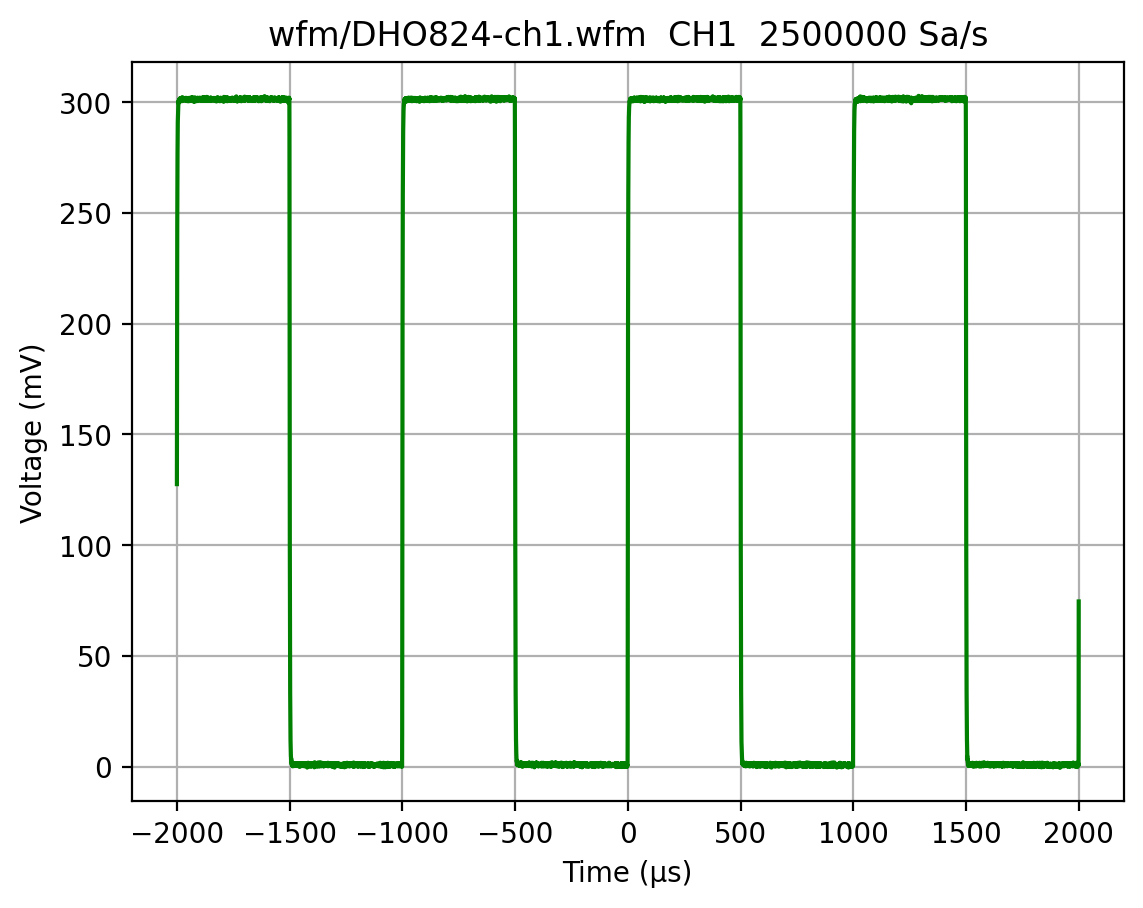

In [4]:
ch = w.channels[0]

plt.plot(ch.times * 1e6, ch.volts * 1000, color="green")
plt.title("%s  CH%d  %.0f Sa/s" % (filename, ch.channel_number, 1 / ch.seconds_per_point))
plt.xlabel("Time (µs)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

## DHO824 - Single-channel `.bin` capture (CH1)

The `.bin` format stores calibrated float32 voltages directly.
No additional scaling is required, and it is identical across all DHO variants.

In [5]:
filename = "bin/DHO824-ch1.bin"
w = Wfm.from_url(repo + filename, "DHO")
print(w.describe())

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/DHO824-ch1.bin'


    General:
        File Model   = DHO800 (BIN)
        User Model   = DHO
        Parser Model = dho1000
        Firmware     = unknown
        Filename     = DHO824-ch1.bin
        Channels     = [1]

    Trigger:
        Derived Level (CH1) = 127.20 mV

     Channel 1:
         Coupling =  unknown
            Scale =     1.00  V/div
           Offset =     0.00  V
            Probe =       1X
         Inverted =    False

        Time Base =  400.000 µs/div
           Offset =    0.000  s
            Delta =  400.000 ns/point
           Points =    10000

         Count    = [        1,        2,        3  ...      9999,    10000]
           Raw    = [      128,      128,      128  ...       128,      128]
           Times  = [-2.000 ms,-2.000 ms,-1.999 ms  ...  1.999 ms, 2.000 ms]
           Volts  = [127.55 mV,169.33 mV,201.53 mV  ...  18.13 mV, 74.57 mV]




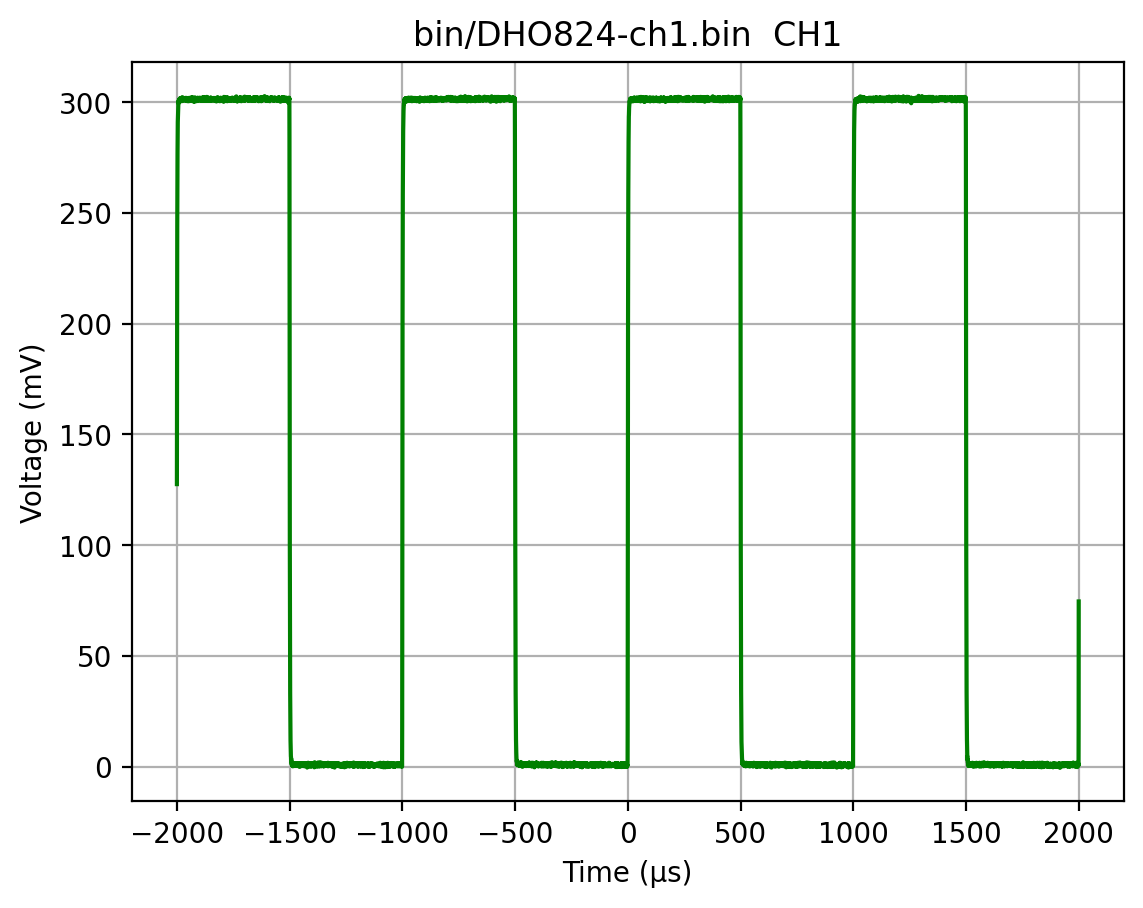

In [6]:
ch = w.channels[0]
plt.plot(ch.times * 1e6, ch.volts * 1000, color="green")
plt.title("%s  CH%d" % (filename, ch.channel_number))
plt.xlabel("Time (µs)")
plt.ylabel("Voltage (mV)")
plt.grid(True)
plt.show()

## DHO824 - Two-channel `.bin` capture (CH1 + CH2)

### Oscilloscope screenshot

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DHO824-ch12.png" width="60%">

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/DHO824-ch12.bin'


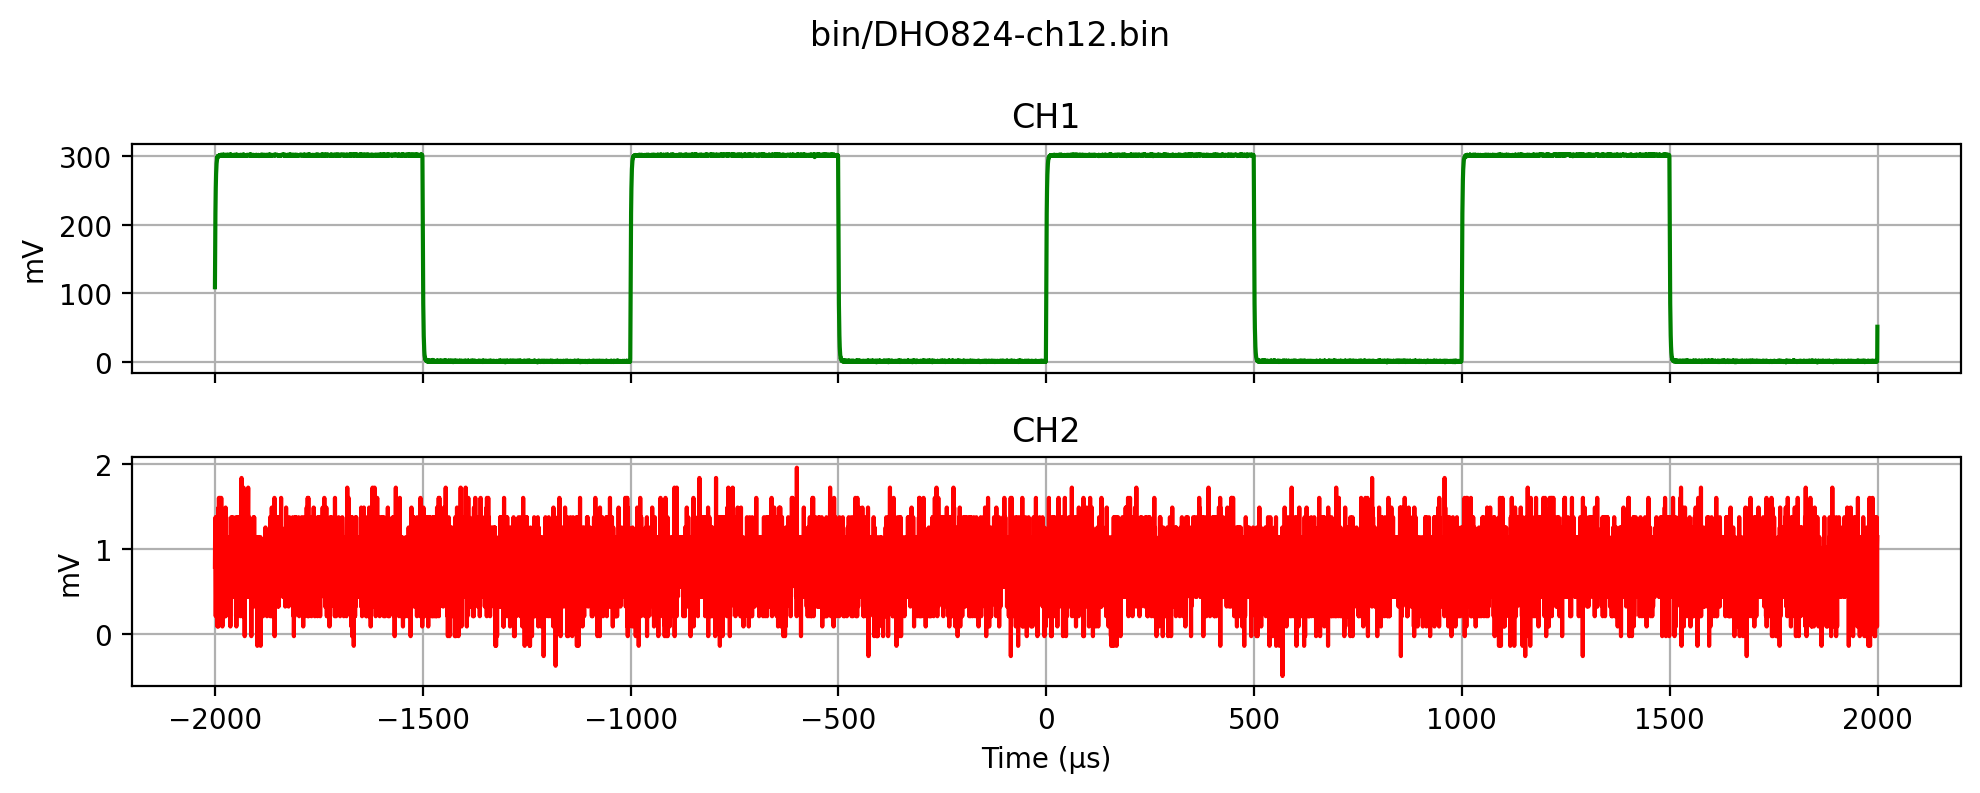

In [7]:
filename = "bin/DHO824-ch12.bin"
w = Wfm.from_url(repo + filename, "DHO", selected="12")

colors = ["green", "red"]
active = [ch for ch in w.channels if ch.volts is not None]

fig, axes = plt.subplots(len(active), 1, sharex=True, figsize=(10, 4))
if len(active) == 1:
    axes = [axes]

for ax, ch, color in zip(axes, active, colors):
    ax.plot(ch.times * 1e6, ch.volts * 1000, color=color)
    ax.set_ylabel("mV")
    ax.set_title("CH%d" % ch.channel_number)
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")
fig.suptitle(filename)
plt.tight_layout()
plt.show()

## DHO824 - Four-channel `.bin` capture (CH1–CH4)

### Oscilloscope screenshot

<img src="https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DHO824-ch1234.png" width="60%">

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/DHO824-ch1234.bin'


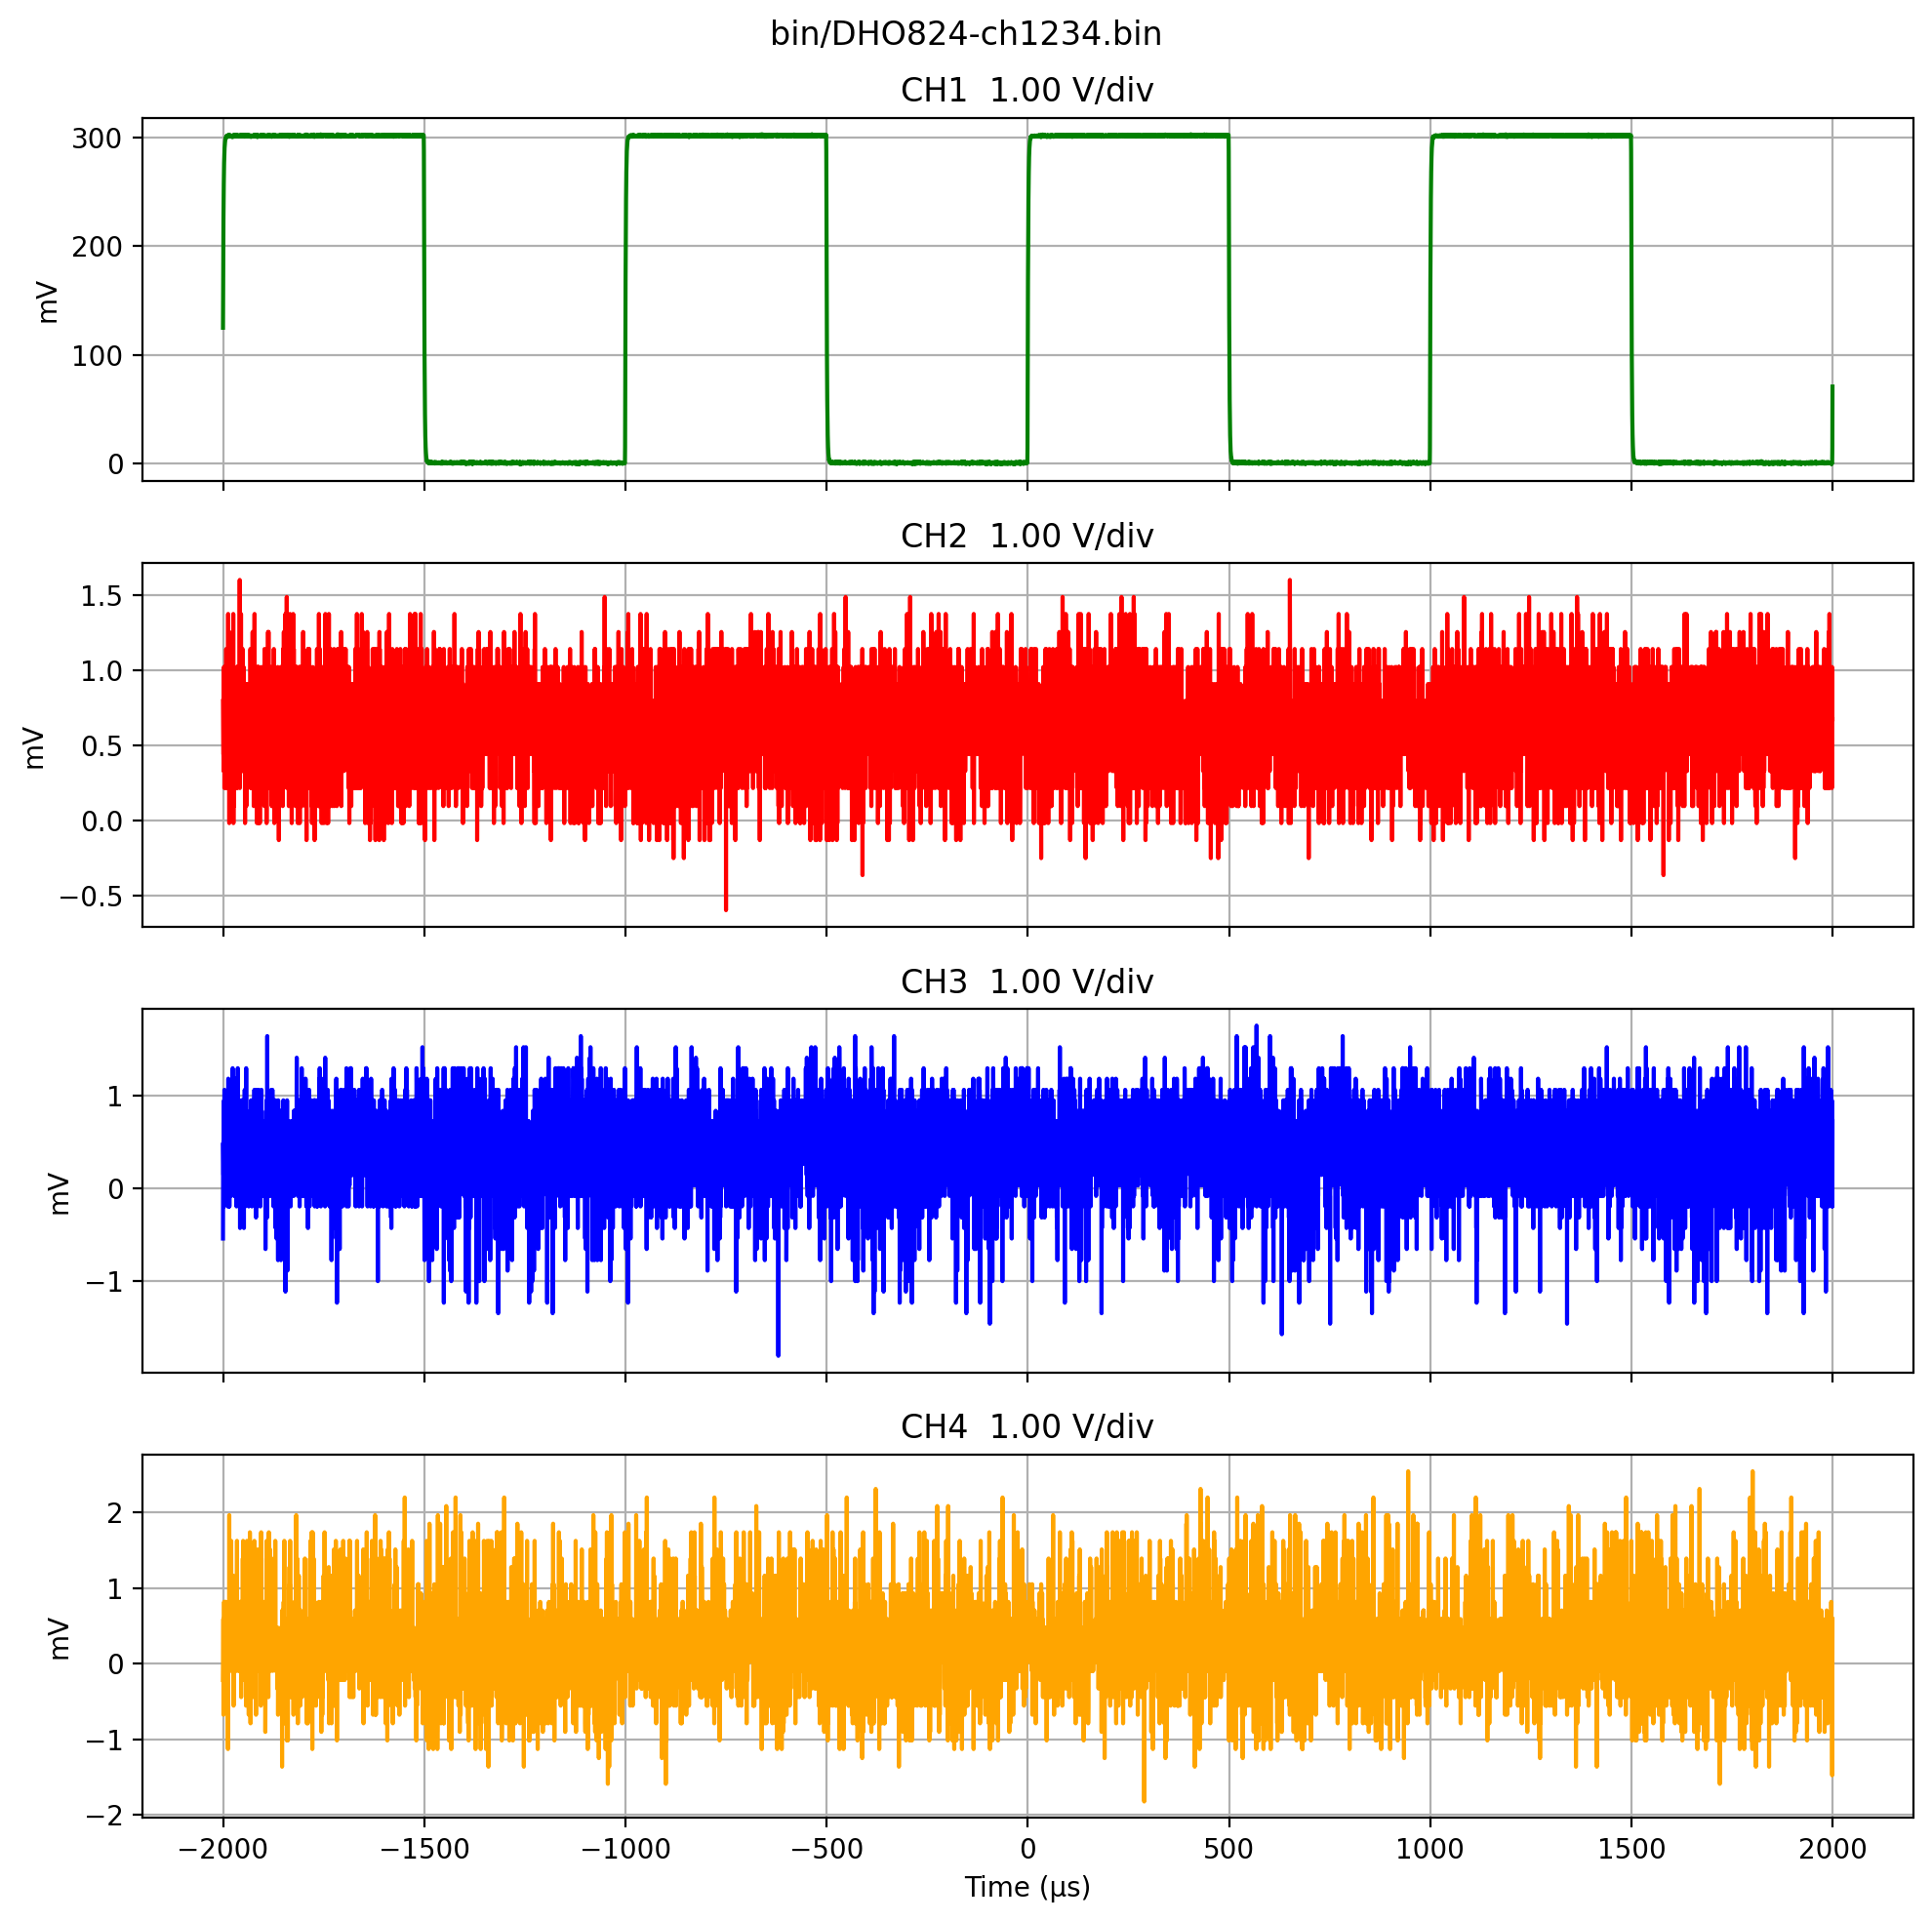

In [8]:
filename = "bin/DHO824-ch1234.bin"
w = Wfm.from_url(repo + filename, "DHO", selected="1234")

colors = ["green", "red", "blue", "orange"]
active = [ch for ch in w.channels if ch.volts is not None]
n = len(active)

fig, axes = plt.subplots(n, 1, sharex=True, figsize=(10, 2.5 * n))
if n == 1:
    axes = [axes]

for ax, ch, color in zip(axes, active, colors):
    ax.plot(ch.times * 1e6, ch.volts * 1000, color=color)
    ax.set_ylabel("mV")
    ax.set_title("CH%d  %.2f V/div" % (ch.channel_number, ch.volt_per_division))
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")
fig.suptitle(filename)
plt.tight_layout()
plt.show()

## DHO824 - Four-channel `.wfm` capture (CH1–CH4)

The `.wfm` parser auto-detects the DHO800 format and deinterleaves the channel data.

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DHO824-ch1234.wfm'


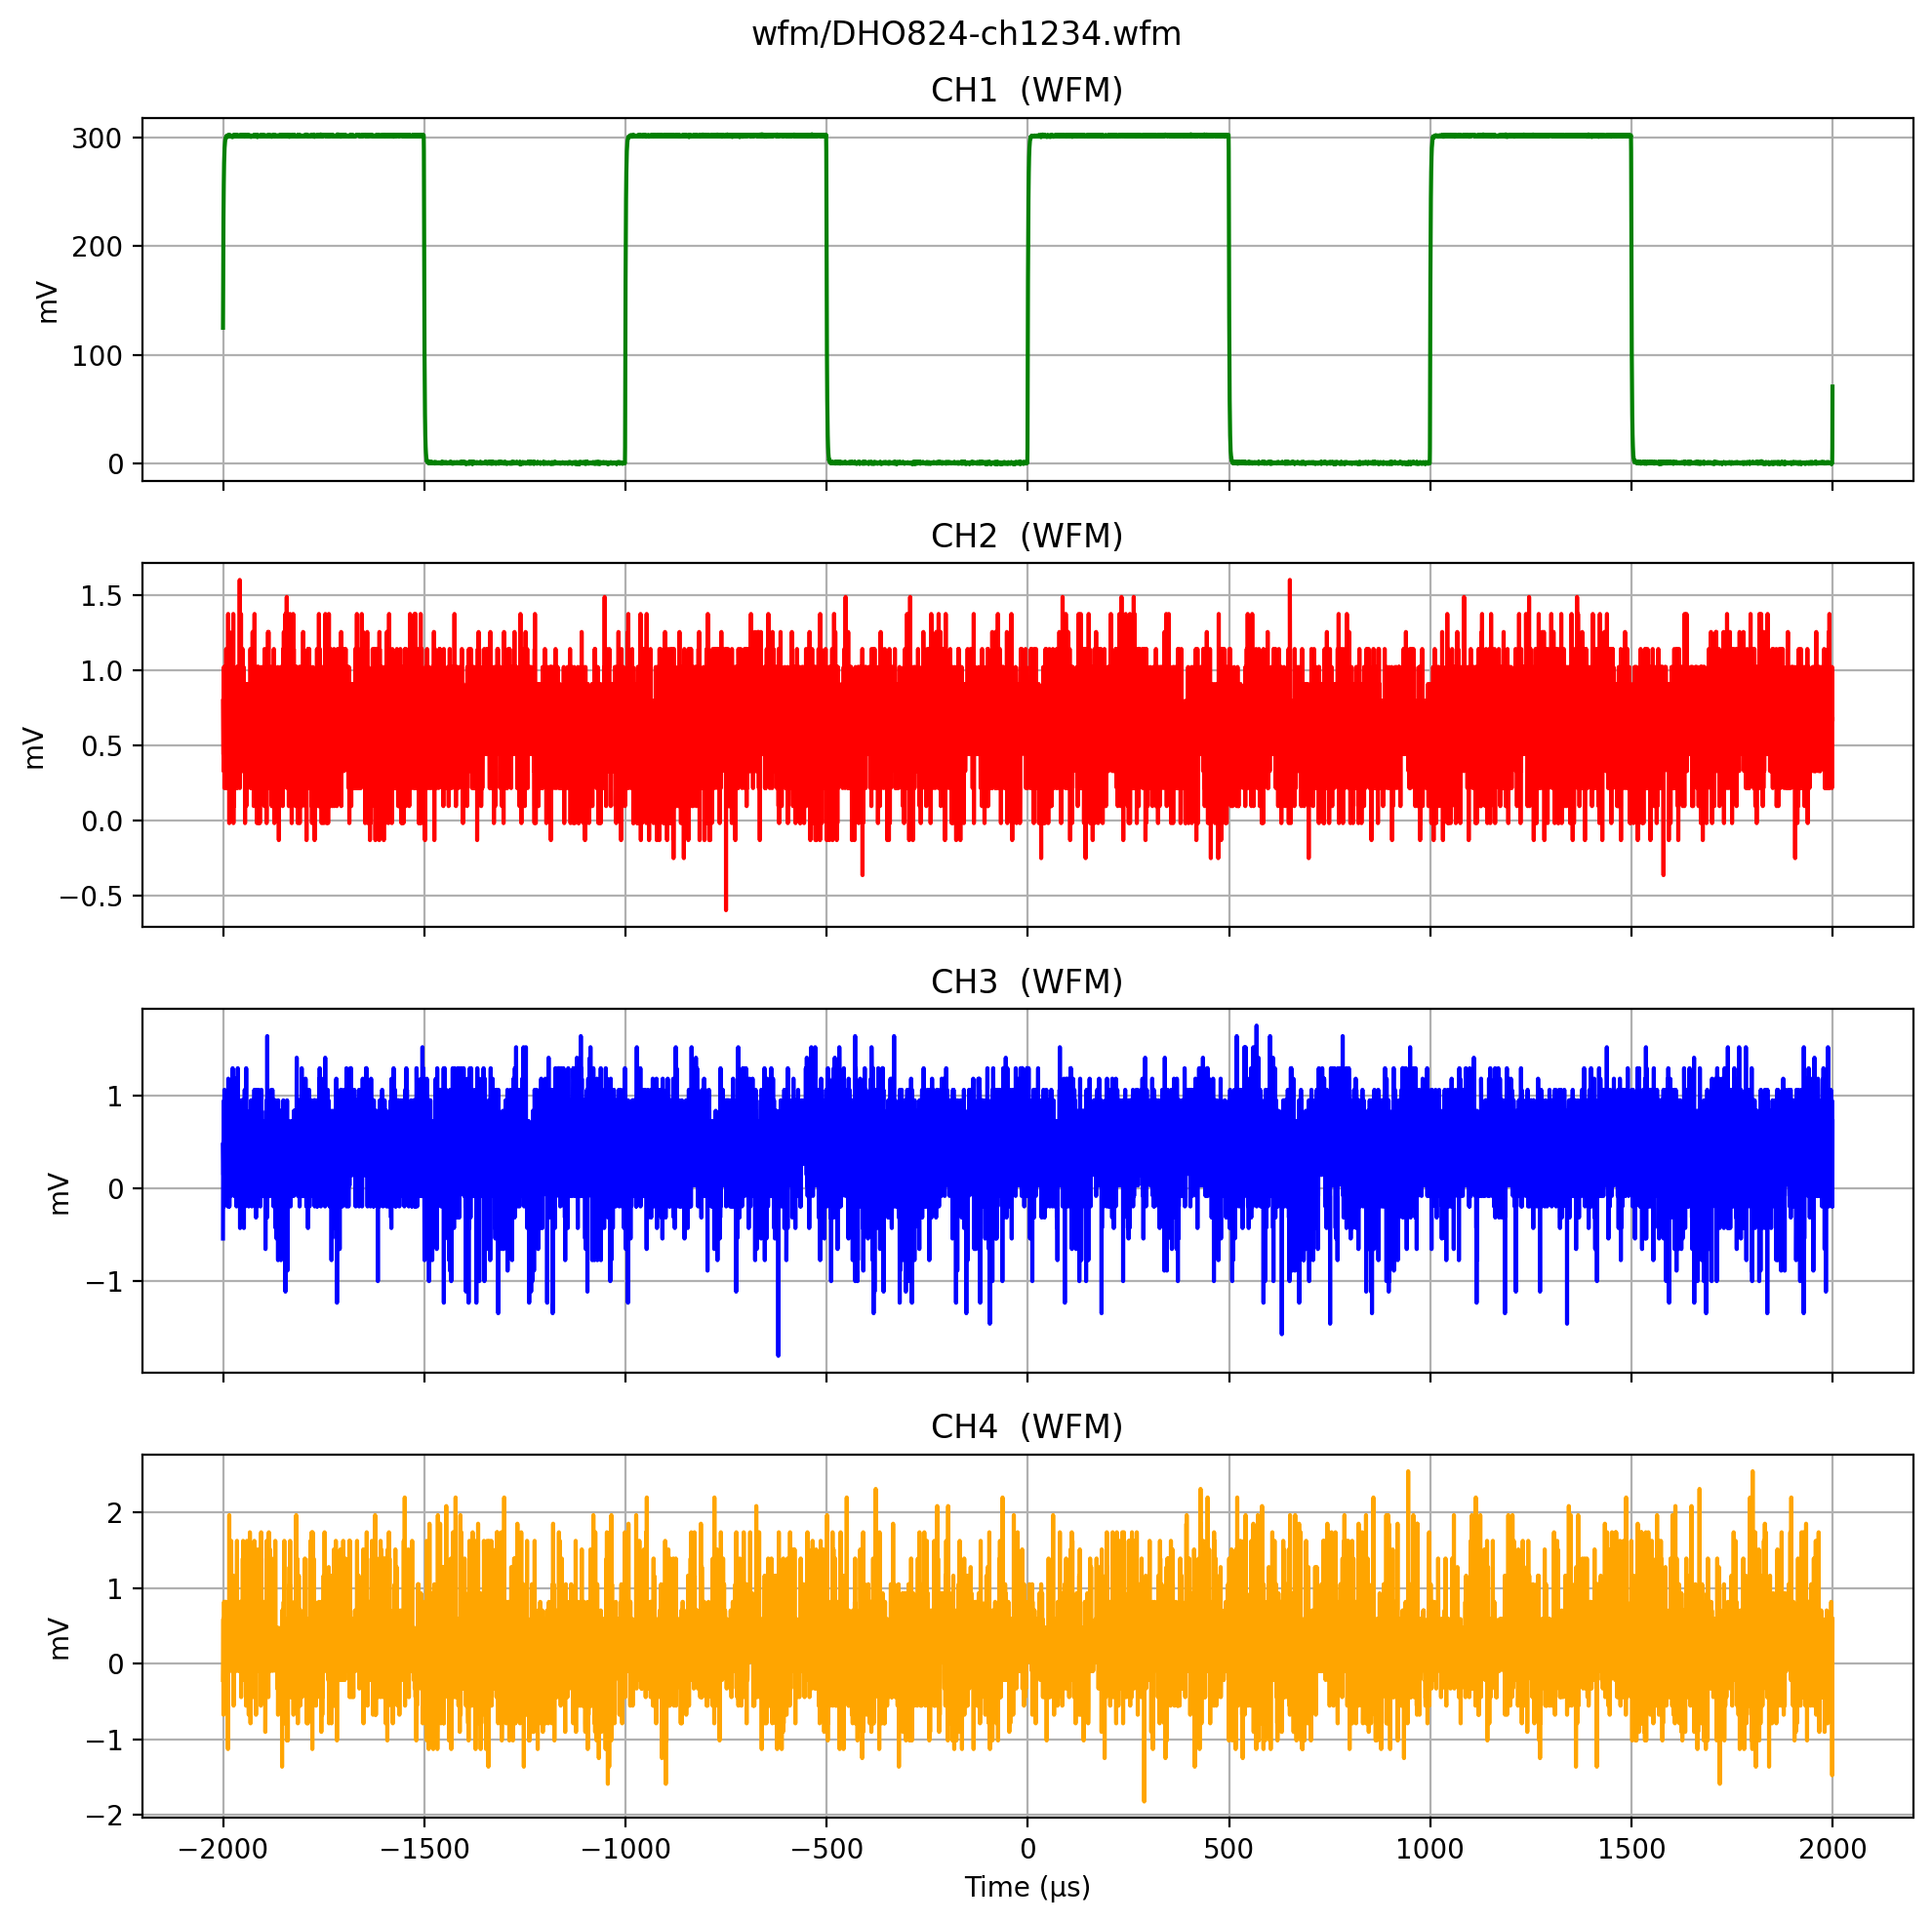

In [9]:
filename = "wfm/DHO824-ch1234.wfm"
w = Wfm.from_url(repo + filename, "DHO", selected="1234")

colors = ["green", "red", "blue", "orange"]
active = [ch for ch in w.channels if ch.volts is not None]
n = len(active)

fig, axes = plt.subplots(n, 1, sharex=True, figsize=(10, 2.5 * n))
if n == 1:
    axes = [axes]

for ax, ch, color in zip(axes, active, colors):
    ax.plot(ch.times * 1e6, ch.volts * 1000, color=color)
    ax.set_ylabel("mV")
    ax.set_title("CH%d  (WFM)" % ch.channel_number)
    ax.grid(True)

axes[-1].set_xlabel("Time (µs)")
fig.suptitle(filename)
plt.tight_layout()
plt.show()

## `.wfm` vs `.bin` comparison for DHO824

Both formats produce identical voltage data (correlation = 1.000, RMS error < 0.006 mV).

downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/wfm/DHO824-ch1.wfm'
downloading 'https://raw.githubusercontent.com/scottprahl/RigolWFM/main/tests/files/bin/DHO824-ch1.bin'


CH1 WFM vs BIN:  correlation = 1.000000,  RMS error = 0.0005 mV


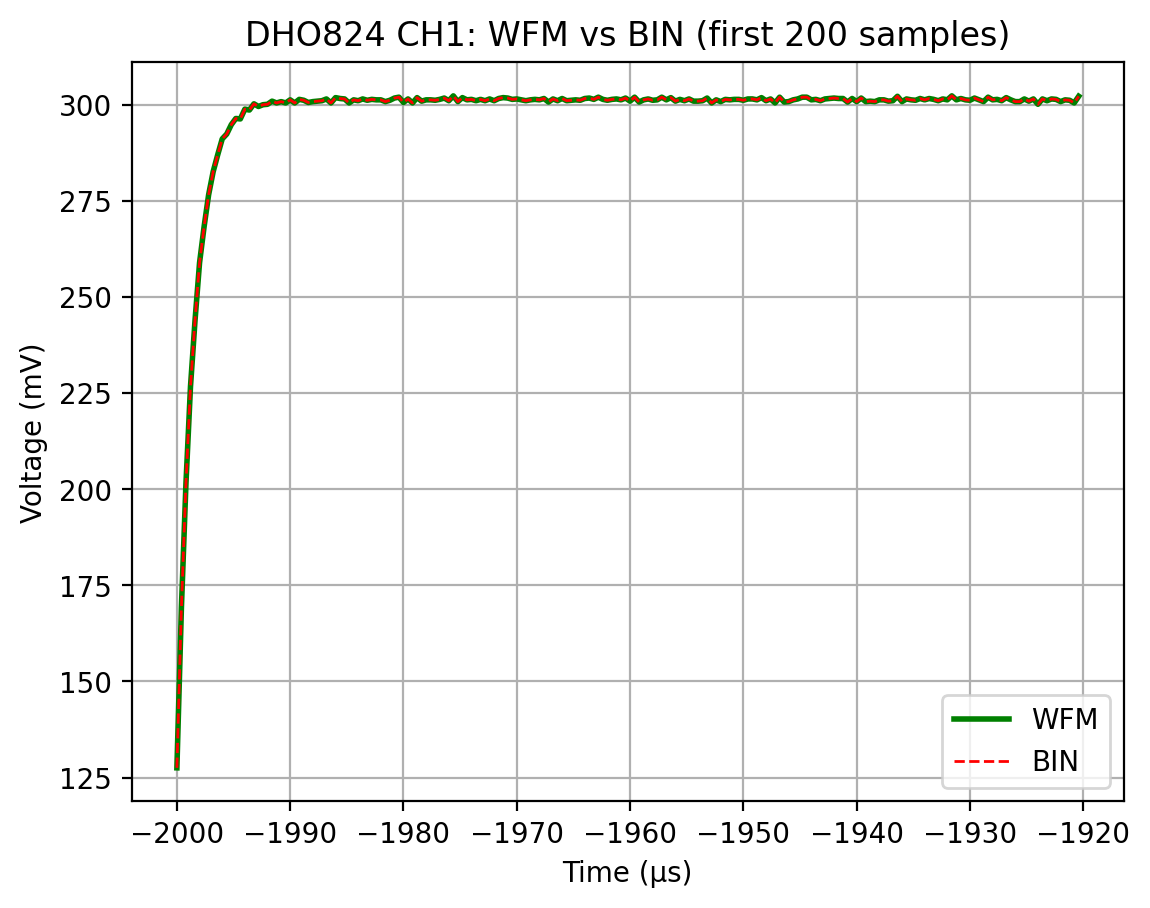

In [10]:
wfm_w = Wfm.from_url(repo + "wfm/DHO824-ch1.wfm", "DHO", selected="1")
bin_w = Wfm.from_url(repo + "bin/DHO824-ch1.bin", "DHO", selected="1")

wfm_v = wfm_w.channels[0].volts
bin_v = bin_w.channels[0].volts
n = min(len(wfm_v), len(bin_v))

corr = np.corrcoef(wfm_v[:n], bin_v[:n])[0, 1]
rms = np.sqrt(np.mean((wfm_v[:n] - bin_v[:n]) ** 2)) * 1000

print(f"CH1 WFM vs BIN:  correlation = {corr:.6f},  RMS error = {rms:.4f} mV")

t = wfm_w.channels[0].times * 1e6
plt.plot(t[:200], wfm_v[:200] * 1000, "g-", label="WFM", linewidth=2)
plt.plot(t[:200], bin_v[:200] * 1000, "r--", label="BIN", linewidth=1)
plt.xlabel("Time (µs)")
plt.ylabel("Voltage (mV)")
plt.title("DHO824 CH1: WFM vs BIN (first 200 samples)")
plt.legend()
plt.grid(True)
plt.show()